## MULTI DATASET CLASSIFICATION

## 🧠 JUSTIFICATION DES CHOIX TECHNIQUES

### 1. Cross-Validation (Validation Croisée)
Plutôt que de se fier à un seul découpage Train/Test, nous utilisons la **Cross-Validation (K-Fold)**. 
- **Pourquoi ?** Cela permet de s'assurer que la performance du modèle est stable et ne dépend pas d'un "coup de chance" lors du split initial. C'est crucial pour valider la robustesse de nos modèles.

### 2. Hyperparameter Tuning (Optimisation des Hyperparamètres)
Chaque algorithme (Logistic Regression, SVM) possède des réglages internes (ex: `C`, `kernel`).
- **Pourquoi ?** Les valeurs par défaut ne sont pas toujours optimales. En utilisant `GridSearchCV`, nous testons systématiquement plusieurs combinaisons pour trouver celle qui maximise le **F1-Score**.

### 3. Analyse d'Erreurs
Au-delà de l'accuracy, nous analysons les **matrices de confusion** et les **exemples mal classés**.
- **Pourquoi ?** Comprendre si le modèle confond le "Négatif" avec le "Neutre" nous permet d'affiner le prétraitement ou de collecter plus de données spécifiques.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer
)
import joblib
import pickle

In [2]:
print('Loading vectors and labels...')
PATH_FEATURES = "../../outputs/results/"
PATH_RAW = "../../data/processed/multilingual_clean.csv"
X_tfidf = load_npz(f"{PATH_FEATURES}multi_tfidf.npz")
X_sbert = np.load(f"{PATH_FEATURES}multi_sbert.npy")
with open(f"{PATH_FEATURES}sbert_metadata_multi.pkl", 'rb') as f:
    metadata = pickle.load(f)
df_full = pd.read_csv(PATH_RAW)
texts_classique = df_full['text_clean_classique'].fillna('').values
texts_light = df_full['text_clean_light'].fillna('').values
texts = texts_classique
y_labels = df_full['sentiment'].fillna('neutral').values
le = LabelEncoder()
y_encoded = le.fit_transform(y_labels)
class_names = le.classes_
print(f"TF-IDF shape: {X_tfidf.shape}")
print(f"SBERT shape: {X_sbert.shape}")
print(f"Classes: {list(class_names)}")

Loading vectors and labels...
TF-IDF shape: (4500, 5000)
SBERT shape: (4500, 384)
Classes: ['negative', 'neutral', 'positive']


### 🔹 CROSS-VALIDATION

In [3]:
# === 🔹 CROSS-VALIDATION (Validation de la robustesse) ===
print("Calcul de la performance moyenne par Cross-Validation (5-folds)...")

# On définit un scorer (F1-weighted est robuste au léger déséquilibre)
scorer = make_scorer(f1_score, average='weighted')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Test sur Logistic Regression + TF-IDF
cv_scores = cross_val_score(LogisticRegression(max_iter=1000, class_weight='balanced'), 
                            X_tfidf, y_encoded, cv=skf, scoring=scorer)

print(f"F1-Score moyen (TF-IDF + LogReg): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Calcul de la performance moyenne par Cross-Validation (5-folds)...
F1-Score moyen (TF-IDF + LogReg): 0.8081 (+/- 0.0346)


In [4]:
idx = np.arange(X_tfidf.shape[0])
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
X_tfidf_train, X_tfidf_test = X_tfidf[idx_train], X_tfidf[idx_test]
X_sbert_train, X_sbert_test = X_sbert[idx_train], X_sbert[idx_test]
texts_c_train, texts_c_test = texts_classique[idx_train], texts_classique[idx_test]
texts_l_train, texts_l_test = texts_light[idx_train], texts_light[idx_test]
print(f"Train: {X_tfidf_train.shape[0]} | Test: {X_tfidf_test.shape[0]}")

Train: 3600 | Test: 900


In [5]:
# === 🔹 HYPERPARAMETER TUNING : LOGISTIC REGRESSION ===
print("Optimisation de la Régression Logistique...")

param_grid_lr = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_lr.fit(X_tfidf_train, y_train)
lr_tfidf = grid_lr.best_estimator_
y_pred_lr = lr_tfidf.predict(X_tfidf_test)

print(f"Meilleurs paramètres : {grid_lr.best_params_}")

Optimisation de la Régression Logistique...


c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
15 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\user\Desktop\S2_IID2\TM\Tps\env311\Lib\site-p

Meilleurs paramètres : {'C': 10.0, 'solver': 'lbfgs'}


In [6]:
# === 🔹 HYPERPARAMETER TUNING : SVM ===
print("Optimisation du SVM...")

param_grid_svm = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_svm.fit(X_tfidf_train, y_train)
svm_tfidf = grid_svm.best_estimator_
y_pred_svm = svm_tfidf.predict(X_tfidf_test)

print(f"Meilleurs paramètres : {grid_svm.best_params_}")

Optimisation du SVM...
Meilleurs paramètres : {'C': 1.0, 'kernel': 'rbf'}


In [7]:
print('Training SBERT + LogReg...')
lr_sbert = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42, solver='lbfgs')
lr_sbert.fit(X_sbert_train, y_train)
y_pred_sbert = lr_sbert.predict(X_sbert_test)
print('SBERT LogReg done.')

Training SBERT + LogReg...
SBERT LogReg done.


In [8]:
def compute_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score': f1_score(y_true, y_pred, average='weighted')
    }
metrics_list = [
    compute_metrics(y_test, y_pred_lr, 'LogReg + TF-IDF'),
    compute_metrics(y_test, y_pred_svm, 'SVM + TF-IDF'),
    compute_metrics(y_test, y_pred_sbert, 'LogReg + SBERT')
]
df_metrics = pd.DataFrame(metrics_list)
print(df_metrics.to_markdown(index=False))
print(classification_report(y_test, y_pred_sbert, target_names=class_names))

| Model           |   Accuracy |   Precision |   Recall |   F1-Score |
|:----------------|-----------:|------------:|---------:|-----------:|
| LogReg + TF-IDF |   0.826667 |    0.82643  | 0.826667 |   0.826363 |
| SVM + TF-IDF    |   0.841111 |    0.842354 | 0.841111 |   0.840699 |
| LogReg + SBERT  |   0.698889 |    0.699301 | 0.698889 |   0.698712 |
              precision    recall  f1-score   support

    negative       0.73      0.71      0.72       300
     neutral       0.69      0.66      0.67       300
    positive       0.68      0.73      0.71       300

    accuracy                           0.70       900
   macro avg       0.70      0.70      0.70       900
weighted avg       0.70      0.70      0.70       900



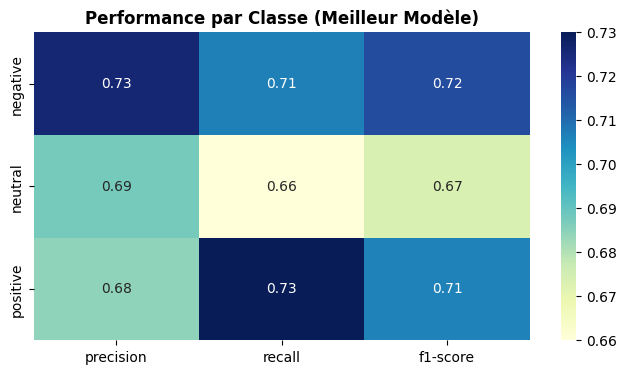

In [9]:
# === 🔹 PERFORMANCE PAR CLASSE (Analyse d'Erreurs détaillée) ===
import seaborn as sns

report = classification_report(y_test, y_pred_sbert, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).transpose().iloc[:len(class_names), :] 

plt.figure(figsize=(8, 4))
sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Performance par Classe (Meilleur Modèle)", fontweight='bold')
plt.show()

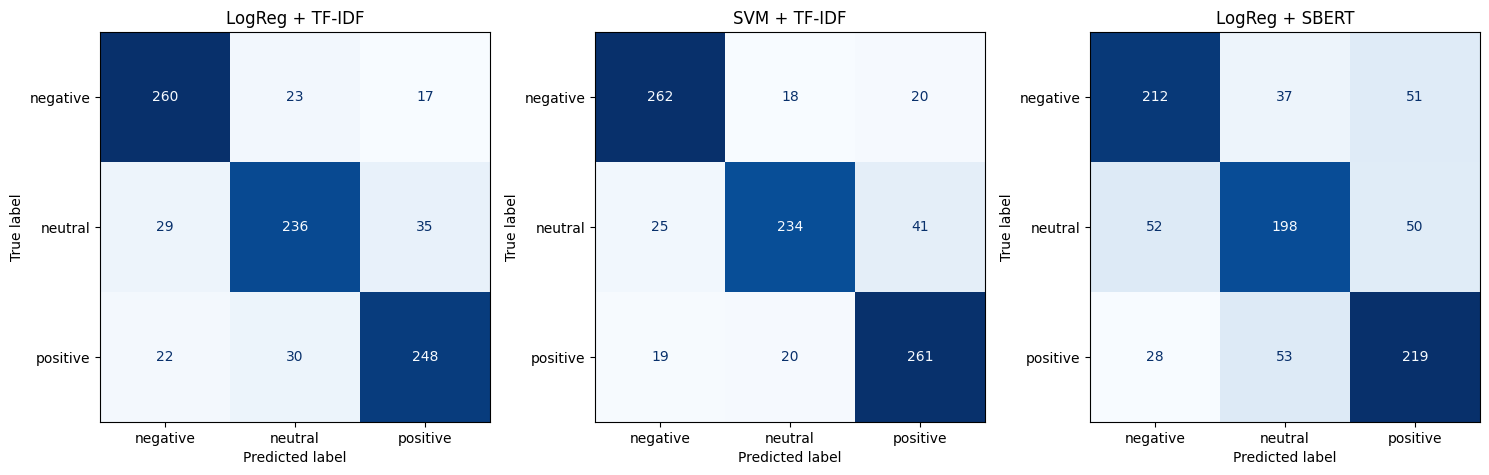

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_preds = [
    (y_pred_lr, 'LogReg + TF-IDF'),
    (y_pred_svm, 'SVM + TF-IDF'),
    (y_pred_sbert, 'LogReg + SBERT')
]
for ax, (preds, name) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds, labels=np.unique(y_test))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [11]:
print('Error analysis for SBERT model...')
misclassified_idx = np.where(y_test != y_pred_sbert)[0]
original_mis_idx = idx_test[misclassified_idx]
print(f"{len(misclassified_idx)} misclassified out of {len(y_test)}")
for i in original_mis_idx[:5]:
    true_label = y_labels[i]
    pred_label = le.inverse_transform([y_pred_sbert[misclassified_idx[np.where(idx_test == i)[0][0]]]])[0]
    text = texts[i][:100]
    print(f"True: {true_label} | Pred: {pred_label}")
    print(f"Text: {text}")

Error analysis for SBERT model...
271 misclassified out of 900
True: positive | Pred: negative
Text: mntouj blastiky loun loumnywm lknh mzyan
True: positive | Pred: negative
Text: hamper cute go well osh kosh quotbears bear everywherequot border valence bedding set picked like fo
True: negative | Pred: negative
Text: look like gift want make gift buy practical
True: neutral | Pred: neutral
Text: daughter almost month cant suck hard enough liquid come tried exert quite bit love doesnt drip leak 
True: positive | Pred: negative
Text: loved swing much bought second one grandma house size made perfect carry house fold small cover remo


In [12]:
import os
os.makedirs("../../outputs/models/", exist_ok=True)
best_model = {
    'vectorizer_type': 'SBERT',
    'model_name': 'LogisticRegression',
    'model': lr_sbert,
    'label_encoder': le,
    'metrics': df_metrics.set_index('Model').loc['LogReg + SBERT'].to_dict()
}
joblib.dump(best_model, "../../outputs/models/best_sentiment_multi.pkl")
print('Saved best model to ../../outputs/models/best_sentiment_multi.pkl')

Saved best model to ../../outputs/models/best_sentiment_multi.pkl
